# Protocol 2 — Message Passing

Agents communicate by **appending messages to a shared list**.  
Each agent reads `state["messages"]` to understand context, then adds its own message.  
The conversation history **IS** the communication channel.

```
messages: [
  HumanMessage("What is 5 + 3?"),
  AIMessage("Routing to add_agent"),   ← supervisor wrote this
  AIMessage("Add result: 8"),          ← add_agent wrote this
  AIMessage("Task complete")           ← supervisor wrote this
]
```

**Rules:**
- Every agent **reads** `state["messages"]` for full context
- Every agent **appends** its output as a new message — never modifies existing ones
- The full history is always available to every agent

In [11]:
# Cell 1: Setup
import re
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage
from langgraph.graph import StateGraph, END
from typing import TypedDict

load_dotenv()
llm = ChatOpenAI(model="gpt-4o-mini")

## State: The messages list IS the channel

Unlike Protocol 1 (where agents write to named fields like `result`),  
Protocol 2 uses a **single `messages` list** as the sole communication channel.

Every agent reads from it and appends to it — that's the entire protocol.

In [12]:
# Cell 2: State — messages list is the communication channel
class State(TypedDict):
    messages: list  # Every agent reads from & writes to this single list
    next: str       # Supervisor sets this to signal routing

## Worker Agents

Each worker:
1. Reads the last `HumanMessage` from the shared history to get its task
2. Does the work
3. **Appends** its result as a new `AIMessage` — never overwrites

This append-only pattern is what creates the audit trail.

In [13]:
# Cell 3: Worker agents — read messages, append results

def _get_task_text(state: State) -> str:
    # For multi-step tasks the supervisor embeds 'Task: <sub-task>' in its routing message.
    # Workers check for that first; fall back to the original HumanMessage.
    task_msg = next(
        (m for m in reversed(state["messages"])
         if isinstance(m, AIMessage) and "Task:" in m.content),
        None
    )
    if task_msg:
        return task_msg.content.split("Task:")[-1].strip()
    return next(m for m in reversed(state["messages"]) if isinstance(m, HumanMessage)).content

def add_agent(state: State) -> State:
    nums = re.findall(r"\d+\.?\d*", _get_task_text(state))
    result = float(nums[0]) + float(nums[1])
    return {
        "messages": state["messages"] + [AIMessage(content=f"Add result: {result}")],
        "next": state["next"]
    }

def multiply_agent(state: State) -> State:
    nums = re.findall(r"\d+\.?\d*", _get_task_text(state))
    result = float(nums[0]) * float(nums[1])
    return {
        "messages": state["messages"] + [AIMessage(content=f"Multiply result: {result}")],
        "next": state["next"]
    }

def subtract_agent(state: State) -> State:
    nums = re.findall(r"\d+\.?\d*", _get_task_text(state))
    result = float(nums[0]) - float(nums[1])
    return {
        "messages": state["messages"] + [AIMessage(content=f"Subtract result: {result}")],
        "next": state["next"]
    }

def divide_agent(state: State) -> State:
    nums = re.findall(r"\d+\.?\d*", _get_task_text(state))
    result = float(nums[0]) / float(nums[1])
    return {
        "messages": state["messages"] + [AIMessage(content=f"Divide result: {result}")],
        "next": state["next"]
    }

## Supervisor Agent

The supervisor also communicates through the message list:
- It appends `"Routing to add_agent"` — so every routing decision is recorded
- When a worker is done, it appends `"Task complete."`
- Nothing is hidden — the full decision log lives in `state["messages"]`

In [14]:
# Cell 4: Supervisor — reads full history, decides what step comes next
def supervisor(state: State) -> State:
    messages = state["messages"]
    original_task = next(m for m in messages if isinstance(m, HumanMessage)).content

    # Build a summary of everything computed so far
    results = [m.content for m in messages if isinstance(m, AIMessage) and "result:" in m.content.lower()]
    results_summary = "\n".join(f"  - {r}" for r in results) if results else "  None yet"
    last_value = results[-1].split(":")[-1].strip() if results else ""

    prompt = f"""You are a math supervisor orchestrating multi-step calculations.

Original task: {original_task}
Results computed so far:
{results_summary}
Last computed value: {last_value}

Workers available: add, multiply, subtract, divide

Decide what to do next:
- If the original task is FULLY complete, reply exactly: END
- Otherwise reply in this EXACT format (two lines):
ROUTE: <worker_name>
TASK: <sub-task with exact numbers, e.g. 'divide 48.0 by 2'>"""

    response = llm.invoke([SystemMessage(content=prompt)])
    text = response.content.strip()

    first_line = text.splitlines()[0].strip().upper()
    if first_line == "END" or first_line.startswith("END"):
        return {"messages": messages + [AIMessage(content="Task complete.")], "next": "END"}

    lines = [l.strip() for l in text.splitlines() if l.strip()]
    route_line = next((l for l in lines if l.upper().startswith("ROUTE:")), "ROUTE: END")
    task_line  = next((l for l in lines if l.upper().startswith("TASK:")),  f"TASK: {original_task}")

    next_agent = route_line.split(":", 1)[-1].strip().lower()
    next_task  = task_line.split(":", 1)[-1].strip()

    # Embed the sub-task in the routing message — workers read "Task:" from here
    routing_msg = AIMessage(content=f"Routing to {next_agent}_agent | Task: {next_task}")
    return {"messages": messages + [routing_msg], "next": next_agent}


def route_supervisor(state: State) -> str:
    return {
        "add":      "add_agent",
        "multiply": "multiply_agent",
        "subtract": "subtract_agent",
        "divide":   "divide_agent",
    }.get(state["next"], END)

In [15]:
# Cell 5: Build the graph
builder = StateGraph(State)

builder.add_node("supervisor",     supervisor)
builder.add_node("add_agent",      add_agent)
builder.add_node("multiply_agent", multiply_agent)
builder.add_node("subtract_agent", subtract_agent)
builder.add_node("divide_agent",   divide_agent)

builder.set_entry_point("supervisor")

builder.add_conditional_edges("supervisor", route_supervisor, {
    "add_agent":      "add_agent",
    "multiply_agent": "multiply_agent",
    "subtract_agent": "subtract_agent",
    "divide_agent":   "divide_agent",
    END: END,
})

builder.add_edge("add_agent",      "supervisor")
builder.add_edge("multiply_agent", "supervisor")
builder.add_edge("subtract_agent", "supervisor")
builder.add_edge("divide_agent",   "supervisor")

app = builder.compile()

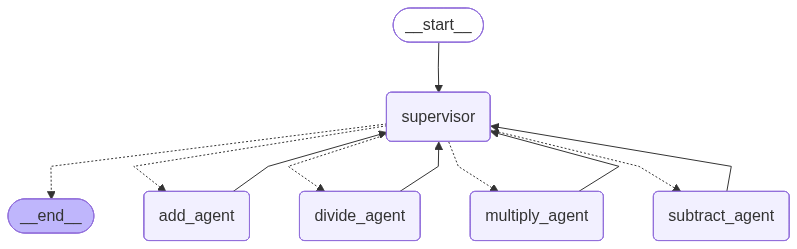

In [16]:
# Cell 6: Visualize the graph
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

## Strength: Full Audit Trail

Every decision is recorded in `state["messages"]`.  
When you print the final message list, you see exactly what happened and why.

In [17]:
# Cell 7: Run and inspect the full message trail
initial_state = {
    "messages": [HumanMessage(content="What is 15 + 27?")],
    "next": ""
}

final_state = app.invoke(initial_state)

print("=" * 52)
print("  FULL MESSAGE TRAIL — Complete Audit Log")
print("=" * 52)
for i, msg in enumerate(final_state["messages"]):
    label = "  Human  " if isinstance(msg, HumanMessage) else "  Agent  "
    print(f"[{i+1}]{label}: {msg.content}")

  FULL MESSAGE TRAIL — Complete Audit Log
[1]  Human  : What is 15 + 27?
[2]  Agent  : Routing to add_agent | Task: add 15 and 27
[3]  Agent  : Add result: 42.0
[4]  Agent  : Routing to end_agent | Task: 


In [18]:
# Cell 8: Multi-step example — multiply THEN divide
# The supervisor now checks after each step whether the full task is done.
# It won't say "Task complete" until BOTH operations have been executed.
initial_state2 = {
    "messages": [HumanMessage(content="Multiply 8 by 6 and divide the result by 2")],
    "next": ""
}

final_state2 = app.invoke(initial_state2)

print("=" * 56)
print("  FULL MESSAGE TRAIL — Multi-Step Task")
print("=" * 56)
for i, msg in enumerate(final_state2["messages"]):
    label = "  Human  " if isinstance(msg, HumanMessage) else "  Agent  "
    print(f"[{i+1}]{label}: {msg.content}")

# Expected trail:
# [1] Human  : Multiply 8 by 6 and divide the result by 2
# [2] Agent  : Routing to multiply_agent | Task: multiply 8 by 6
# [3] Agent  : Multiply result: 48.0
# [4] Agent  : Routing to divide_agent | Task: divide 48.0 by 2
# [5] Agent  : Divide result: 24.0
# [6] Agent  : Task complete.

  FULL MESSAGE TRAIL — Multi-Step Task
[1]  Human  : Multiply 8 by 6 and divide the result by 2
[2]  Agent  : Routing to multiply_agent | Task: multiply 8 by 6
[3]  Agent  : Multiply result: 48.0
[4]  Agent  : Routing to divide_agent | Task: divide 48.0 by 2
[5]  Agent  : Divide result: 24.0
[6]  Agent  : Task complete.


## Weakness: Messages Grow Indefinitely

Because we only append — never trim — the message list grows with every task.  
In a long-running agent session, this creates two problems:

1. **Context limit** — LLMs have a max token window; a massive history will overflow it
2. **Cost** — longer prompts cost more tokens per call

The simulation below shows how quickly the list can grow across multiple tasks.

In [19]:
# Cell 9: Simulate growing messages across multiple tasks
state = {"messages": [], "next": ""}

tasks = [
    "What is 5 + 3?",
    "What is 10 multiplied by 2?",
    "What is 100 minus 45?",
    "What is 7 + 8?",
    "Multiply 9 by 4",
]

print(f"{'Task':<30} {'Messages After'}") 
print("-" * 45)

for task in tasks:
    state["messages"].append(HumanMessage(content=task))
    state = app.invoke(state)
    print(f"{task:<30} {len(state['messages'])} messages in history")

print()
print(f"Final message count: {len(state['messages'])} messages")
print("Every new task adds ~3-4 messages — this never stops growing!")

Task                           Messages After
---------------------------------------------
What is 5 + 3?                 4 messages in history
What is 10 multiplied by 2?    6 messages in history
What is 100 minus 45?          8 messages in history
What is 7 + 8?                 10 messages in history
Multiply 9 by 4                12 messages in history

Final message count: 12 messages
Every new task adds ~3-4 messages — this never stops growing!


In [20]:
# Cell 10: Print the final bloated message trail
print("=" * 52)
print(f"  FINAL STATE: {len(state['messages'])} messages accumulated")
print("=" * 52)
for i, msg in enumerate(state["messages"]):
    label = "  Human  " if isinstance(msg, HumanMessage) else "  Agent  "
    print(f"[{i+1:>2}]{label}: {msg.content}")

  FINAL STATE: 12 messages accumulated
[ 1]  Human  : What is 5 + 3?
[ 2]  Agent  : Routing to add_agent | Task: add 5 to 3
[ 3]  Agent  : Add result: 8.0
[ 4]  Agent  : Task complete.
[ 5]  Human  : What is 10 multiplied by 2?
[ 6]  Agent  : Task complete.
[ 7]  Human  : What is 100 minus 45?
[ 8]  Agent  : Task complete.
[ 9]  Human  : What is 7 + 8?
[10]  Agent  : Task complete.
[11]  Human  : Multiply 9 by 4
[12]  Agent  : Task complete.


## Summary

| Aspect | Protocol 2 Behavior |
|--------|---------------------|
| **Channel** | Single shared `messages` list |
| **How agents write** | Append a new message — never overwrite |
| **How agents read** | Scan `state["messages"]` for relevant context |
| **Audit trail** | Full — every routing decision is a message |
| **Weakness** | History grows unboundedly; hits context limits |
| **Best for** | Short-lived tasks, debugging, transparency |

---

**This is exactly what you've been doing in all your LangGraph code:**

```python
return {"messages": state["messages"] + [AIMessage(content="...")]}
```

Protocol 3 introduces fixes for the growing-message problem:  
**trimming**, **summarizing**, or **windowing** the message history.